In [2]:
import wandb
from glob import glob
import pandas
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Results for PPO, PD Control and Baseline

In [67]:
mean = {"baseline": [], "PPO_rs25": [], "PPO_rs50": []}
std = {"baseline": [], "PPO_rs25": [], "PPO_rs50": []}
ra = [10000, 100000, 1000000, 5000000]

# read from csv
for method in mean.keys():
    for ra_elem in ra:
            if method == "baseline":
                path = f"res/{method}_ra{ra_elem}.csv"
            else:
                path = f"res/{method}_ra{ra_elem}_nusselt.csv"
            try:
                df = pandas.read_csv(path)

                # mean per episode
                df = df.groupby('episode').mean()
                mean[method].append(df["nusselt"].mean())
                std[method].append(df["nusselt"].std())
            except Exception as e:
                mean[method].append(0)
                std[method].append(0)

# # compute percentage
mean_percent = {"baseline": [], "PPO_rs25": [], "PPO_rs50": []}
std_percent = {"baseline": [], "PPO_rs25": [], "PPO_rs50": []}
for idx in range(len(mean["baseline"])):
    for method in mean.keys():
        b = mean["baseline"][idx]
        mean_percent[method].append(100 - (100 * mean[method][idx] / b))
        std_percent[method].append(100 * std[method][idx] / b)

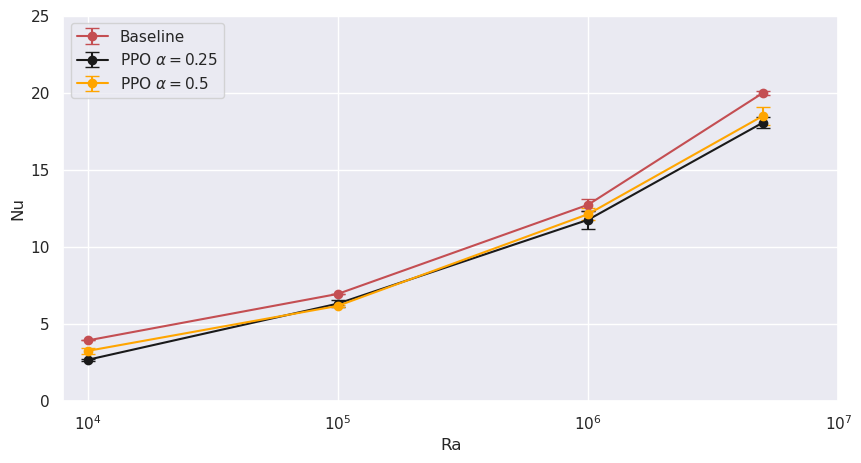

In [75]:
# plot
plt.figure(figsize=(10, 5))
sns.set_theme()

# x axis
plt.xlim(8000, 10000000)
plt.xticks(ticks=[10000, 100000, 1000000, 10000000], labels=["$10^4$","$10^5$","$10^6$", "$10^7$"])
plt.xlabel("Ra")
plt.xscale("log")

# y axis
plt.ylim(0, 25)
#plt.yscale("log")
plt.ylabel("Nu")

# plot data
plt.errorbar(ra, mean["baseline"], std["baseline"], linestyle="-", marker='o', color='r', capsize=5, label="Baseline")
plt.errorbar(ra, mean["PPO_rs25"], std["PPO_rs25"], linestyle="-", marker='o', color='k', capsize=5, label=r"PPO $\alpha=0.25$")
plt.errorbar(ra, mean["PPO_rs50"], std["PPO_rs50"], linestyle="-", marker='o', color='orange', capsize=5, label=r"PPO $\alpha=0.5$")

plt.legend()
plt.show()

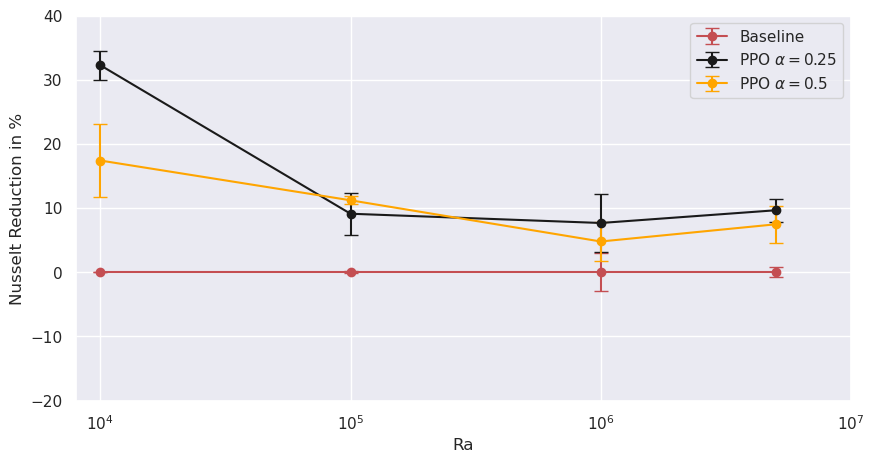

In [76]:
# plot
plt.figure(figsize=(10, 5))
sns.set_theme()

# x axis
plt.xlim(8000, 10000000)
plt.xticks(ticks=[10000, 100000, 1000000, 10000000], labels=["$10^4$","$10^5$","$10^6$", "$10^7$"])
plt.xlabel("Ra")
plt.xscale("log")

# y axis
plt.ylim(-20, 40)
plt.ylabel("Nusselt Reduction in %")

# plot data
plt.errorbar(ra, mean_percent["baseline"], std_percent["baseline"], linestyle="-", marker='o', color='r', capsize=5, label="Baseline")
plt.errorbar(ra, mean_percent["PPO_rs25"], std_percent["PPO_rs25"], linestyle="-", marker='o', color='k', capsize=5, label=r"PPO $\alpha=0.25$")
plt.errorbar(ra, mean_percent["PPO_rs50"], std_percent["PPO_rs50"], linestyle="-", marker='o', color='orange', capsize=5, label=r"PPO $\alpha=0.5$")


plt.legend()
plt.show()

In [ ]:
# NOTE: Figures for generalization to different ra, or percentage reaching one cell state, or time to reach one cell state.

# plot
plt.figure(figsize=(10, 5))
sns.set_theme()

# x axis
plt.xlim(8000, 10000000)
plt.xticks(ticks=[10000, 100000, 1000000, 10000000], labels=["$10^4$","$10^5$","$10^6$", "$10^7$"])
plt.xlabel("Ra")
plt.xscale("log")

# y axis
plt.ylim(-20, 40)
plt.ylabel("Nusselt Reduction in %")

# plot data
plt.errorbar(ra, mean_percent["ppo"], std_percent["ppo"], linestyle="-", marker='o', capsize=5, label="PPO")
plt.errorbar(ra, mean_percent["ppo_ra10000"], std_percent["ppo_ra10000"], linestyle="-", marker='o', capsize=5, label="PPO ra10000")
plt.errorbar(ra, mean_percent["ppo_ra100000"], std_percent["ppo_ra100000"], linestyle="-", marker='o', capsize=5, label="PPO ra100000")


plt.legend()
plt.show()

In [131]:
# What is the percentage of episodes that reach a one cell state?
# read from csv
csv_files = [
     "PPO_rs25_ra10000_cell_dist.csv",
     "PPO_rs50_ra100000_cell_dist.csv",
     "PPO_rs50_ra1000000_cell_dist.csv",
     "PPO_rs50_ra5000000_cell_dist.csv"
     ]
ra = [10000, 100000, 1000000, 5000000]
percentages_one_cell_rs = []
thres = 0.8
nr_episodes = 20

for file in csv_files:
    path = f"res/{file}"
    try:
        df = pandas.read_csv(path)
        episodes_one_cell = 0
        for idx_group, episode_df in df.groupby('episode'):
            # strategy: If among the last 10% of the episode, there is at least 80% with a cell distance of 0, then we consider it a one cell state.
            last_10_percent = int(0.1 * len(episode_df))
            episode_df.iloc[-last_10_percent:]
            one_cell_state = episode_df.iloc[-last_10_percent:].cell_dist == 0
            if one_cell_state.sum() / last_10_percent >= thres:
                episodes_one_cell += 1
        percentages_one_cell_rs.append(episodes_one_cell / nr_episodes) 
        # print(f"Percentage of episodes that reach one cell state: {episodes_one_cell / nr_episodes}")
    except Exception as e:
        print(e)

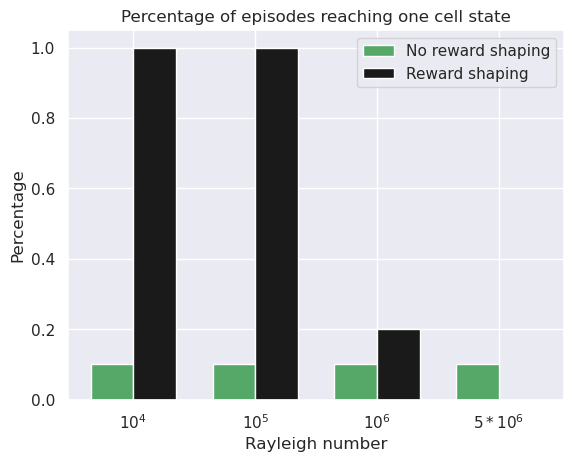

In [132]:
# Make a simple bar chart to show the result (with reward shaping and without reward shaping)
# Sample data
categories = [r'$10^4$', r'$10^5$', r'$10^6$', r'$5*10^6$']
values_group1 = [0.1, 0.1, 0.1, 0.1]
values_group2 = percentages_one_cell_rs

x = np.arange(len(categories))  # x locations for groups
width = 0.35  # Width of bars

fig, ax = plt.subplots()

# Plot bars for both groups
bars1 = ax.bar(x - width/2, values_group1, width, color='g', label='No reward shaping')
bars2 = ax.bar(x + width/2, values_group2, width, color='k', label='Reward shaping')

# Labels and title
ax.set_xlabel("Rayleigh number")
ax.set_ylabel("Percentage")
ax.set_title("Percentage of episodes reaching one cell state")
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

# Show the plot
plt.show()

In [ ]:
# Last plot: time to reach one cell state
# Approach: What is the first window of 10% of the episode where the cell distance is 0 for at least 80% of the time?
# This makes sense only for ra=10000 and ra=100000
csv_files = ["PPO_rs25_ra10000_cell_dist.csv", "PPO_rs50_ra100000_cell_dist.csv"]
ra = [10000, 100000]
times_to_reach_one_cell = []
for file in csv_files: